In [1]:
# ---- Robust DABAM → multi-page PDF (auto-discover + hardened) ----
from pathlib import Path
import re, shutil, math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib import colors as mcolors

# Your environment imports
import darkfield.VIBE as VIBE
from darkfield.VIBE import load_dabam2d

# ------------- USER SETTINGS -------------
OUT_PDF = "dabam_maps.pdf"   # final output file
DABAM_ROOT = None            # None → default (…/darkfield/Dabam2D/data)
CMAP = "GnBu"                # or "RdBu_r", "coolwarm"
PERCENT_CLIP = (2, 98)       # None to use raw min/max
MAX_META_LINES = 14
MAX_SIDE_PIXELS = 2200       # downsample if either side exceeds this (keeps PDF lighter)
VERBOSE = True               # print progress
# ----------------------------------------


def _resolve_dabam_root(dabam_root=None) -> Path:
    if dabam_root is None:
        return Path(VIBE.__file__).parent / "Dabam2D" / "data"
    return Path(dabam_root)


def _discover_dabam_indices(dabam_root=None):
    root = _resolve_dabam_root(dabam_root)
    idxs = []
    for p in root.glob("dabam2d-*.h5"):
        m = re.search(r"dabam2d-(\d{4})\.h5$", p.name, flags=re.IGNORECASE)
        if m:
            idxs.append(int(m.group(1)))
    return sorted(set(idxs))


def _nice_meta(meta: dict, max_lines: int = 14) -> str:
    preferred = [
        "USER_REFERENCE", "MATERIAL", "FACILITY", "INSTRUMENT",
        "SURFACE_SHAPE", "FUNCTION", "FOCUS_DIR",
        "WIDTH", "LENGTH", "THICK", "RS", "RM",
        "YEAR_FABRICATION", "SCAN_DATE", "SUBSTRATE", "COATING", "POLISHING"
    ]
    lines = []

    def _fmt_kv(k, v):
        if k in ("WIDTH", "LENGTH", "THICK", "RS", "RM"):
            try:
                val = float(v)
                if abs(val) < 5e-3:   # < 5 mm
                    return f"{k}: {val*1e6:.0f} µm"
                if abs(val) < 5:
                    return f"{k}: {val*1e3:.2f} mm"
                return f"{k}: {val:.3g} m"
            except Exception:
                pass
        return f"{k}: {v}"

    for k in preferred:
        if k in meta and str(meta[k]).strip():
            lines.append(_fmt_kv(k, meta[k]))
    for k in sorted(meta.keys()):
        if k in preferred:
            continue
        v = meta[k]
        if v is None or str(v).strip() == "":
            continue
        lines.append(_fmt_kv(k, v))

    if len(lines) > max_lines:
        lines = lines[:max_lines] + [f"... (+{len(lines)-max_lines} more)"]
    return "\n".join(lines) if lines else "No metadata found"


def _safe_percentiles(z, prc):
    try:
        vmin, vmax = np.nanpercentile(z, list(prc))
        if not np.isfinite(vmin) or not np.isfinite(vmax) or vmin == vmax:
            raise ValueError
        return vmin, vmax
    except Exception:
        # fall back to finite min/max
        zf = z[np.isfinite(z)]
        if zf.size == 0:
            return 0.0, 1.0
        vmin, vmax = float(np.nanmin(zf)), float(np.nanmax(zf))
        if vmin == vmax:
            vmax = vmin + (abs(vmin) if vmin != 0 else 1.0)
        return vmin, vmax


def _auto_norm(z_um: np.ndarray, percent_clip=(2, 98)):
    if percent_clip:
        vmin, vmax = _safe_percentiles(z_um, percent_clip)
    else:
        vmin, vmax = _safe_percentiles(z_um, (0, 100))
    if vmin < 0 < vmax:
        return mcolors.TwoSlopeNorm(vcenter=0.0, vmin=vmin, vmax=vmax)
    return mcolors.Normalize(vmin=vmin, vmax=vmax)


def _downsample_if_needed(Z, X, Y, max_side=MAX_SIDE_PIXELS):
    """Downsample arrays if too large, preserving extent."""
    ny, nx = Z.shape
    if nx <= max_side and ny <= max_side:
        return Z, X, Y
    sx = math.ceil(nx / max_side)
    sy = math.ceil(ny / max_side)
    Zs = Z[::sy, ::sx]
    Xs = X[::sx]
    Ys = Y[::sy]
    return Zs, Xs, Ys


def _validate_data(X, Y, Z):
    # shape checks
    if Z.ndim != 2:
        return False, "Z is not 2D"
    ny, nx = Z.shape
    if nx < 2 or ny < 2:
        return False, "Z too small"
    if X.ndim != 1 or Y.ndim != 1 or X.size != nx or Y.size != ny:
        return False, "X/Y shape mismatch"
    # finite data check
    if not np.isfinite(Z).any():
        return False, "Z has no finite values"
    # extent checks (degenerate span)
    if not np.isfinite([X.min(), X.max(), Y.min(), Y.max()]).all():
        return False, "non-finite extent"
    if X.min() == X.max() or Y.min() == Y.max():
        return False, "zero span extent"
    return True, ""


def _plot_one(ax, idx: int, X, Y, Z_m, meta, cmap, percent_clip, max_meta_lines):
    # optional downsampling (for huge maps)
    Zm, Xr, Yr = _downsample_if_needed(Z_m, X, Y)

    ok, msg = _validate_data(Xr, Yr, Zm)
    if not ok:
        raise ValueError(f"Invalid data for {idx:04d}: {msg}")

    extent_um = [float(Xr.min()*1e6), float(Xr.max()*1e6),
                 float(Yr.min()*1e6), float(Yr.max()*1e6)]
    Z_um = Zm * 1e6

    im = ax.imshow(
        Z_um,
        extent=extent_um,
        origin="lower",
        cmap=cmap,
        norm=_auto_norm(Z_um, percent_clip=percent_clip),
        aspect="equal"
    )
    cb = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cb.set_label("Height [µm]")

    ax.set_title(f"DABAM2D-{idx:04d} — raw surface")
    ax.set_xlabel("x [µm]")
    ax.set_ylabel("y [µm]")

    txt = _nice_meta(meta, max_lines=max_meta_lines)
    ax.text(
        0.99, 0.99, txt,
        transform=ax.transAxes,
        ha="right", va="top",
        fontsize=9,
        color="black",
        bbox=dict(boxstyle="round,pad=0.35", facecolor="white", alpha=0.85, edgecolor="0.4"),
    )

    # scale bar
    try:
        span_um = min(abs(extent_um[1]-extent_um[0]), abs(extent_um[3]-extent_um[2]))
        bar = 0.1 * span_um
        x0 = extent_um[0] + 0.08 * (extent_um[1]-extent_um[0])
        y0 = extent_um[2] + 0.08 * (extent_um[3]-extent_um[2])
        ax.plot([x0, x0+bar], [y0, y0], lw=3, color="k")
        ax.text(x0+bar/2, y0 + 0.03*span_um, f"{bar:.0f} µm", ha="center", va="bottom")
    except Exception:
        pass


def dabam_to_pdf_safe(
    out_pdf: str | Path = OUT_PDF,
    dabam_root: str | Path | None = DABAM_ROOT,
    cmap: str = CMAP,
    percent_clip = PERCENT_CLIP,
    max_meta_lines: int = MAX_META_LINES,
    verbose: bool = VERBOSE
):
    """
    Auto-discovers DABAM entries and writes a multi-page PDF safely.
    Uses a temporary PDF and renames on success. Skips bad pages.
    """
    out_pdf = Path(out_pdf)
    out_pdf.parent.mkdir(parents=True, exist_ok=True)
    tmp_pdf = out_pdf.with_suffix(".tmp.pdf")

    indices = _discover_dabam_indices(dabam_root)
    if not indices:
        raise RuntimeError(f"No dabam2d-####.h5 files found in {_resolve_dabam_root(dabam_root)}")

    skipped = []
    plotted = 0

    if verbose:
        print(f"Found {len(indices)} entries. Writing to temp: {tmp_pdf}")

    # Write to a temp file so a crash never corrupts your good PDF
    try:
        with PdfPages(tmp_pdf) as pdf:
            for idx in indices:
                try:
                    if verbose and plotted % 10 == 0:
                        print(f"  plotting index {idx:04d} ...")
                    X, Y, Z_m, meta = load_dabam2d(int(idx), dabam_root)

                    fig, ax = plt.subplots(figsize=(8.2, 6.6), dpi=140)
                    _plot_one(ax, idx, X, Y, Z_m, meta, cmap, percent_clip, max_meta_lines)
                    fig.tight_layout()

                    # save one page — this is inside try/except to catch write errors
                    pdf.savefig(fig)
                    plt.close(fig)
                    plotted += 1

                except FileNotFoundError:
                    skipped.append((idx, "missing file"))
                except Exception as exc:
                    skipped.append((idx, str(exc)))
                    plt.close('all')  # ensure figures are closed on error
                    continue
    except Exception as exc:
        # If writing the PDF itself failed, remove temp to avoid confusion
        if tmp_pdf.exists():
            tmp_pdf.unlink(missing_ok=True)
        raise

    # If we got here, the temp PDF closed cleanly — promote it
    if plotted == 0:
        tmp_pdf.unlink(missing_ok=True)
        raise RuntimeError("No valid pages produced; aborting.")
    shutil.move(str(tmp_pdf), str(out_pdf))

    msg = f"✓ Wrote {out_pdf.resolve()} with {plotted} page(s)."
    if skipped:
        msg += f" Skipped {len(skipped)} entries (first few): {skipped[:8]}{' …' if len(skipped) > 8 else ''}"
    print(msg)


# ------------- RUN (auto-discover all) -------------
dabam_to_pdf_safe(OUT_PDF, dabam_root=DABAM_ROOT)


Found 131 entries. Writing to temp: dabam_maps.tmp.pdf
  plotting index 0001 ...
  plotting index 0011 ...
  plotting index 0021 ...
  plotting index 0031 ...
  plotting index 0041 ...
  plotting index 0051 ...
  plotting index 0061 ...
  plotting index 0071 ...
  plotting index 0081 ...
  plotting index 0091 ...
  plotting index 0101 ...
  plotting index 0111 ...
  plotting index 1003 ...
  plotting index 2001 ...
✓ Wrote /home/yu79deg/darkfield_p5438/notebooks/dabam_maps.pdf with 131 page(s).


In [1]:
import barc4ro.wavefront_fitting as wft
import h5py
import numpy as np
from scipy.interpolate import interp2d, interp1d
import matplotlib.pyplot as plt


In [2]:
def average_azimuthal(_input, x_axis, y_axis, _center=(0, 0), _range_r=(0, -1), _delta_r=1, _range_theta=(0, -1),
                      _delta_theta=1, _mask=None):

    """

    :param _input:
    :param _center:
    :param _range_r:
    :param _delta_r:
    :param _range_theta:
    :param _delta_theta:
    :param _mask:
    :return:
    """

    def _f_xy(_theta, _rho):
        x = _rho*np.cos(_theta)
        y = _rho*np.sin(_theta)
        return x, y

    xStart = x_axis[0]
    xFin = x_axis[-1]
    nx = x_axis.size

    yStart = y_axis[0]
    yFin = y_axis[-1]
    ny = y_axis.size

    # ********************** generating auxiliary vectors

    x_cen = 0.5*(xFin + xStart)
    y_cen = 0.5*(yFin + yStart)

    _range_r = list(_range_r)
    _range_theta = list(_range_theta)

    if _range_r[1] == -1:
        if xFin - x_cen > yFin - y_cen:
            _range_r[1] = 1 * (yFin - y_cen)
        else:
            _range_r[1] = 1 * (xFin - x_cen)

    if _range_theta[1] == -1:
        _range_theta[1] = 2*np.pi

    nr = int(nx*_delta_r/2)
    ntheta = int((_range_theta[1] - _range_theta[0])*360 * _delta_theta/2/np.pi)

    X = np.linspace(xStart, xFin, nx)
    Y = np.linspace(yStart, yFin, ny)

    R = np.linspace(_range_r[0],_range_r[1], nr)
    THETA = np.linspace(_range_theta[0],_range_theta[1], ntheta)

    azimuthal_average = np.zeros([nr])
    azimuthal_value = np.zeros([ntheta])

    # ********************** summation

    f = interp2d(X, Y, _input)

    if _mask is not None:
        f_mask = interp2d(X, Y, _mask)

    m = 0

    for rho in R:
        n = 0
        summation = 0
        for angle in THETA:
            x, y = _f_xy(angle, rho)

            if _mask is not None:
                point = f_mask(x, y)
            else:
                point = 1
            if point >= 0.5:
                azimuthal_value[n] = f(x, y)
                summation += 1
            n += 1

        azimuthal_average[m] = np.sum(azimuthal_value)/summation
        m = m+1

    return azimuthal_average, R

In [3]:
def remove_avg_profile(profile, mask, x, y, averaged_profile, ax, direction):
    """

    :param profile:
    :param x:
    :param y:
    :param averaged_profile:
    :param R:
    :param direction:
    :return:
    """
    X, Y = np.meshgrid(x, y)

    if direction == 'v':
        averaged_profile = np.transpose(averaged_profile)
    f_av_profile = interp1d(ax, averaged_profile, bounds_error=False, fill_value=0)
    if direction == 'b':
        R = np.sqrt(X**2 + Y**2)
    elif direction == 'v':
        R = Y
    else:
        R = X

    avg_profile = f_av_profile(R)

    if mask is not None:
        avg_profile[np.logical_not(mask)] = 0

    return avg_profile, (profile - avg_profile)

In [4]:
file_name = r'C:\Users\rafae\Work\projects\dabam2d\data\dabam2d-0001.h5'

file = h5py.File(file_name, 'r')
xx = file["surface_file" + "/X"][()]
yy = file["surface_file" + "/Y"][()]
zz = file["surface_file" + "/Z"][()]
file.close()

In [5]:
Zcoeffs, Zfit, Zresidues = wft.fit_zernike_circ(zz, nmodes=37, startmode=1, rec_zern=True)

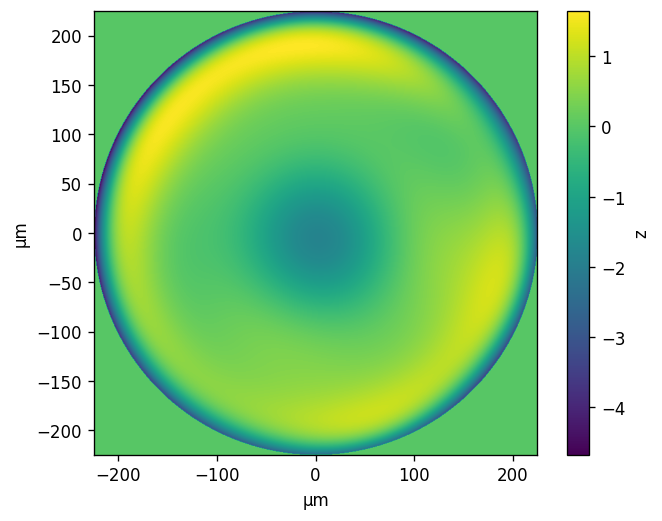

In [6]:
fig, ax = plt.subplots(dpi=120)
im = ax.imshow(
    Zfit*1e6,
    extent=[xx.min()*1e6, xx.max()*1e6, yy.min()*1e6, yy.max()*1e6],
    origin='lower',
    aspect='equal',
    cmap='viridis'
)
ax.set_xlabel("µm")
ax.set_ylabel("µm")
fig.colorbar(im, ax=ax, label="z")
plt.show()

In [15]:
def get_rho_phi(shape):
    """

    :param shape:
    :return:
    """
    x_axis = np.linspace(-1, 1, shape[1])
    y_axis = np.linspace(-1, 1, shape[0])
    X, Y = np.meshgrid(x_axis, y_axis)
    rho = np.sqrt(X ** 2 + Y ** 2)
    phi = np.arctan2(Y, X)
    return rho, phi

In [8]:
rho, phi = get_rho_phi(Zfit.shape)
# noll notation - 10th Zernike
zn = 11
Z10=Zcoeffs[zn-1]*wft.zernike_circ(zn, rho, phi, norm=True) 


In [9]:
def get_mask(img, edges, shape, ap_or_ob):
    """

    :param img: image to be masked
    :param edges: coordinates for the mask in [yi, yf, xi, xf]
    :param shape: 'r' for rectangle, 'c' for circle, 'e' for ellipse
    :param ap_or_ob: 'a' for aperture (True in, False out), 'o' for obstacle (False in, True out)
    :return: mask
    """

    mask = np.zeros(img.shape, dtype=bool)

    X, Y = np.meshgrid(np.linspace(0, img.shape[1]-1, img.shape[1]),
                       np.linspace(0, img.shape[0]-1, img.shape[0]))

    if shape == 'r':

        mask[X < edges[2]] = True
        mask[X > edges[3]] = True
        mask[Y < edges[0]] = True
        mask[Y > edges[1]] = True
        mask = np.logical_not(mask)

    elif shape == 'c':

        yc = (edges[1] + edges[0])/2
        xc = (edges[3] + edges[2])/2

        R = ((X-xc) ** 2 + (Y-yc) ** 2) ** 0.5

        radius = (edges[1]-edges[0] + edges[3]-edges[2])/4

        mask[R <= radius] = True

    elif shape == 'e':
        pass

    if ap_or_ob == 'o':
        mask = np.logical_not(mask)

    return mask

In [10]:
mask = get_mask(zz, [0, zz.shape[0], 0, zz.shape[1]], 'c', 'a')

In [11]:
removedZ = (Zfit-Z10)*1e6

In [12]:
removedZ[np.logical_not(mask)] = 0

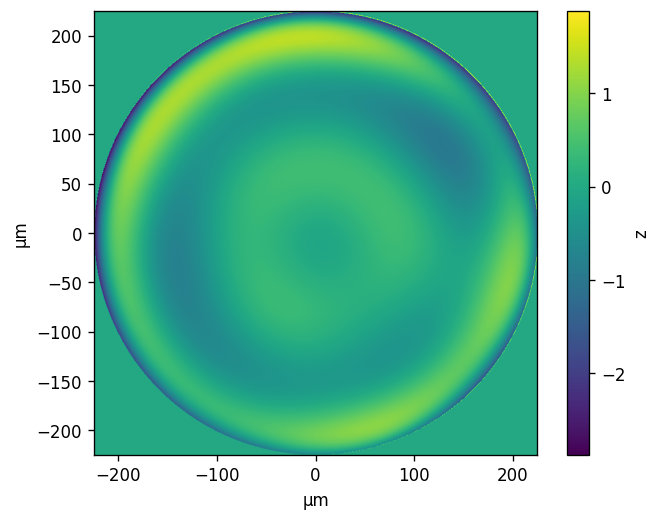

In [13]:
fig, ax = plt.subplots(dpi=120)
im = ax.imshow(
    removedZ,
    extent=[xx.min()*1e6, xx.max()*1e6, yy.min()*1e6, yy.max()*1e6],
    origin='lower',
    aspect='equal',
    cmap='viridis'
)
ax.set_xlabel("µm")
ax.set_ylabel("µm")
fig.colorbar(im, ax=ax, label="z")
plt.show()

In [ ]:
I_thick_res, R = average_azimuthal(Zresidues, xx, yy)


In [ ]:
Cfit, Cresidues = remove_avg_profile(Zresidues, None, xx, yy, I_thick_res, R, 'b')

In [ ]:
fig, ax = plt.subplots(dpi=120)
im = ax.imshow(
    Zfit*1e6,
    extent=[xx.min()*1e6, xx.max()*1e6, yy.min()*1e6, yy.max()*1e6],
    origin='lower',
    aspect='equal',
    cmap='viridis'
)
ax.set_xlabel("µm")
ax.set_ylabel("µm")
fig.colorbar(im, ax=ax, label="z")
plt.show()

In [ ]:
fig, ax = plt.subplots(dpi=120)
im = ax.imshow(
    Cfit*1e6,
    extent=[xx.min()*1e6, xx.max()*1e6, yy.min()*1e6, yy.max()*1e6],
    origin='lower',
    aspect='equal',
    cmap='viridis'
)
ax.set_xlabel("µm")
ax.set_ylabel("µm")
fig.colorbar(im, ax=ax, label="z")
plt.show()

In [ ]:
fig, ax = plt.subplots(dpi=120)
im = ax.imshow(
    Zresidues*1e6,
    extent=[xx.min()*1e6, xx.max()*1e6, yy.min()*1e6, yy.max()*1e6],
    origin='lower',
    aspect='equal',
    cmap='viridis'
)
ax.set_xlabel("µm")
ax.set_ylabel("µm")
fig.colorbar(im, ax=ax, label="z")
plt.show()

In [ ]:
fig, ax = plt.subplots(dpi=120)
im = ax.imshow(
    Cresidues*1e6,
    extent=[xx.min()*1e6, xx.max()*1e6, yy.min()*1e6, yy.max()*1e6],
    origin='lower',
    aspect='equal',
    cmap='viridis'
)
ax.set_xlabel("µm")
ax.set_ylabel("µm")
fig.colorbar(im, ax=ax, label="z")
plt.show()

In [13]:
#========= MY CODE ==========

from darkfield.VIBE import load_dabam2d
from darkfield import wavefront_fitting as wft
import matplotlib.pyplot as plt
import numpy as np

X, Y, Z, meta = load_dabam2d(80)
print(X.shape, Y.shape, Z.shape)
print(meta.get("RM", meta.get("surface_name", "no metadata")))


(613,) (613,) (613, 613)
0.0000963


In [14]:

# Fits the surface up to the 37th Zernike polynomial. The rest is called "residus"
Zcoeffs, Zfit, Zresidues = wft.fit_zernike_circ(Z, nmodes=37, startmode=1, rec_zern=True)
print(Zcoeffs)


[ 9.02689974e-09 -1.08420259e-09 -1.08596666e-09  1.41504205e-09
 -2.18276896e-07 -2.66056246e-07  3.83719594e-07  1.98380249e-07
 -5.84132635e-08 -2.34708125e-09 -1.06574617e-07  2.13176991e-08
 -3.12581210e-08  7.32836316e-08  1.00784166e-07  2.91648623e-08
 -6.62839729e-08 -1.52035072e-09  4.06705558e-08 -2.28337780e-08
  2.00947453e-08 -3.07790442e-07  2.50840404e-08  6.29593549e-08
 -9.05628533e-08 -7.54874674e-08  1.35616012e-09  1.35223438e-08
 -7.18257062e-08  1.40912269e-08  2.66099522e-08  5.03574884e-09
 -2.59773888e-08  7.10859478e-09  2.63273620e-08  6.35797585e-09
 -7.75356285e-08]


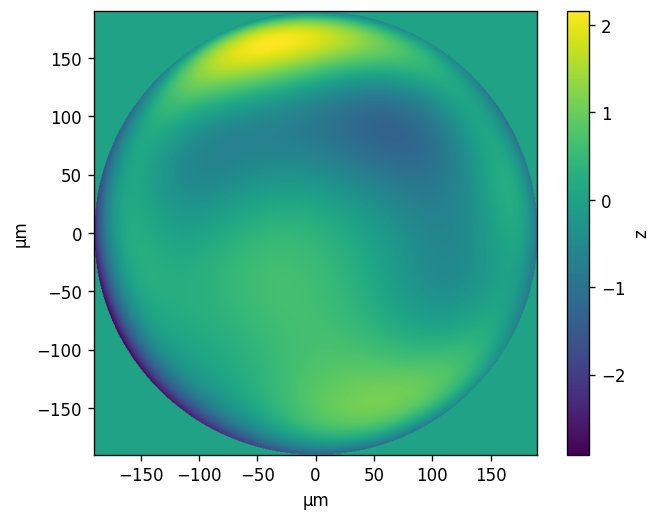

In [15]:

fig, ax = plt.subplots(dpi=120)
im = ax.imshow(
    (Zfit)*1e6,
    extent=[X.min()*1e6, X.max()*1e6, Y.min()*1e6, Y.max()*1e6],
    origin='lower',
    aspect='equal',
    cmap='viridis'
)
ax.set_xlabel("µm")
ax.set_ylabel("µm")
fig.colorbar(im, ax=ax, label="z")
plt.show()

In [ ]:
rho, phi = get_rho_phi(Zfit.shape)
# noll notation - 10th Zernike
zn = 11
Z10=Zcoeffs[zn-1]*wft.zernike_circ(zn, rho, phi, norm=True) 





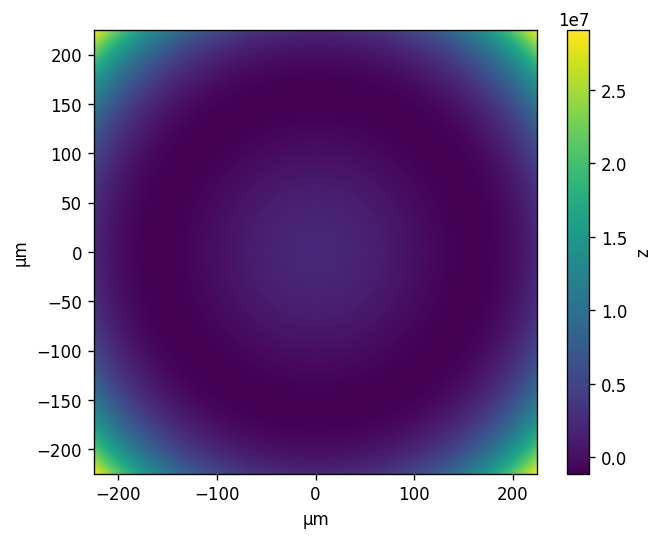

In [33]:

fig, ax = plt.subplots(dpi=120)
im = ax.imshow(
    Z10*1e6,
    extent=[X.min()*1e6, X.max()*1e6, Y.min()*1e6, Y.max()*1e6],
    origin='lower',
    aspect='equal',
    cmap='viridis'
)
ax.set_xlabel("µm")
ax.set_ylabel("µm")
fig.colorbar(im, ax=ax, label="z")
plt.show()